In [ ]:
#!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------- ----------- 5.8/8.0 MB 31.6 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 26.9 MB/s  0:00:00
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   -------------- ------------------------- 12.8/36.5 MB 63.0 MB/s eta 0:00:01
   --------------------------- ------------ 25.4/36.5 MB 57.7 MB/s eta 0:00:01
   ----------------------------------- ---- 32.8/36.5 MB 54.7 MB/s eta 0:00:01
   ---------------------------------------- 36.5/36.5 MB 41.3 MB/s  0:00:00

   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ------------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\ameti\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Chargement du dataset prêt pour le Machine Learning
chemin_fichier = '../data/application_train_cleaned.csv'
df = pd.read_csv(chemin_fichier)

print(f"Taille du dataset : {df.shape}")

Taille du dataset : (307511, 216)


In [16]:
y = df['TARGET']
X = df.drop(columns=["TARGET"])

# Séparation des données (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#Tailles des splits
print(f"Taille de X_train : {X_train.shape}")
print(f"Taille de X_test  : {X_test.shape}")

Taille de X_train : (246008, 215)
Taille de X_test  : (61503, 215)


In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:

modele_lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

modele_lr.fit(X_train_scaled, y_train)

y_pred = modele_lr.predict(X_test_scaled)


=== Matrice de Confusion ===


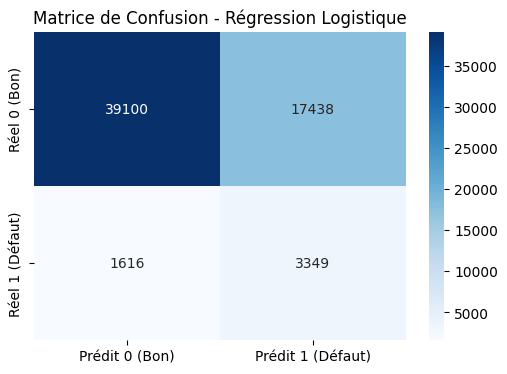


=== Rapport de Classification ===
              precision    recall  f1-score   support

           0       0.96      0.69      0.80     56538
           1       0.16      0.67      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.90      0.69      0.76     61503



In [24]:
# 1. Matrice de confusion visuelle
print("=== Matrice de Confusion ===")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
# On utilise Seaborn pour faire une belle carte de chaleur (heatmap)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Prédit 0 (Bon)', 'Prédit 1 (Défaut)'], 
            yticklabels=['Réel 0 (Bon)', 'Réel 1 (Défaut)'])
plt.title('Matrice de Confusion - Régression Logistique')
plt.show()

# 2. Rapport de classification (Les métriques détaillées)
print("\n=== Rapport de Classification ===")
print(classification_report(y_test, y_pred))